# Heart Disease Prediction using Logistic Regression

## Problem Statement

The objective of this project is to build a binary classification
model that predicts whether a patient is likely to have heart disease
based on clinical features.

## Objective

We want to build a model that can distinguish between:

- 0 → No heart disease
- 1 → Heart disease

Since a false negative can be more dangerous in this application,
we pay particular attention to recall for the positive class.

## Machine Learning Type

- Supervised Learning
- Binary Classification
- Classification Algorithm: Logistic Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('heart.csv')


## Understanding the Dataset 

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.shape

(303, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

## EDA

 For Continuous Values - we need statistics (Desrcibe),histogram(to observe median and overlapping),boxplot,feature vs target 

In [10]:
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [11]:
df["target"].value_counts(normalize=True) * 100

target
1    54.455446
0    45.544554
Name: proportion, dtype: float64

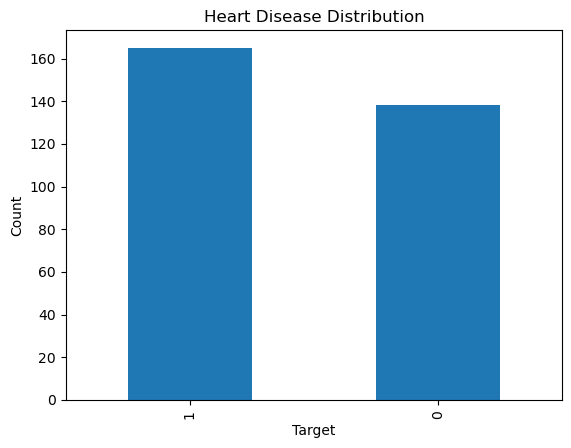

In [12]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="bar")

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

# Age - continuous value

In [13]:
df["age"].describe()

count    303.000000
mean      54.366337
std        9.082101
min       29.000000
25%       47.500000
50%       55.000000
75%       61.000000
max       77.000000
Name: age, dtype: float64

In [14]:
# Q3-Q1
#Q3=61    Q1=47.5
# IQR=Q3-Q1=61-47.5=13.5
# lower bound=Q1-1.5*IQR=  47.5-1.5*13.5=27.25
# upper bound=Q3+1.5*IQR=  61+1.5*13.5=81.25

# minimum > lower bound  29 > 27.25
# maximum < upper bound  77 < 81.25
# hence no outliers

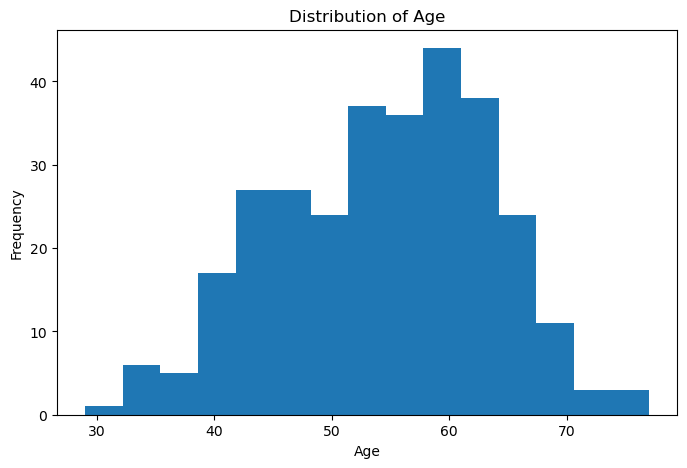

In [15]:
# distribution of age 
# we need to know is it left skewed or right skewed or normal distribution

plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=15)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

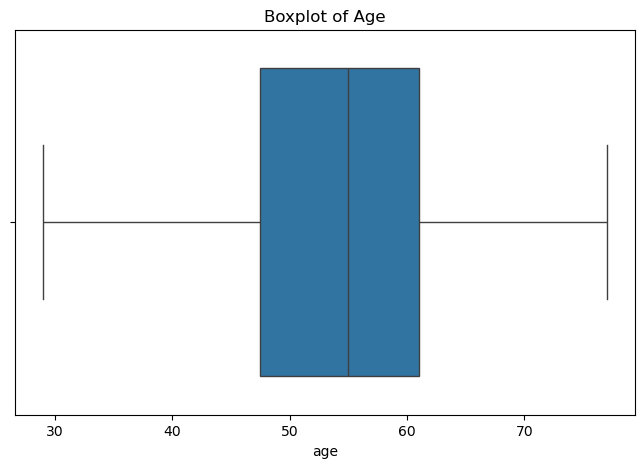

In [16]:
# boxplot of age
plt.figure(figsize=(8,5))

sns.boxplot(x=df["age"])

plt.title("Boxplot of Age")

plt.show()

In [17]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

# trestbps-resting blood pressure  -continuous value

In [18]:
df["trestbps"].describe()

count    303.000000
mean     131.623762
std       17.538143
min       94.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

In [19]:
# Q3-Q1
#Q3=140    Q1=120
# IQR=Q3-Q1=140-120=20
# lower bound=Q1-1.5*IQR=  120-1.5*20=90
# upper bound=Q3+1.5*IQR=  140+1.5*20=170

# minimum > lowerbound        94 >90
# maximum < upper bound       200 > 170( there are outliers )
# there are outliers

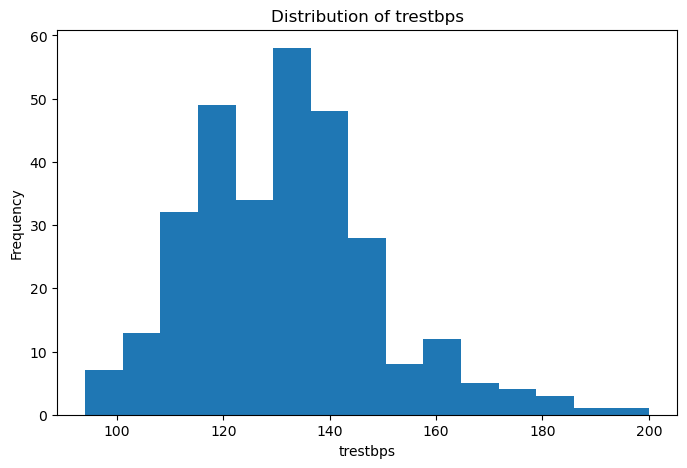

In [20]:
# distribuiton of  trestbps


plt.figure(figsize=(8,5))
plt.hist(df["trestbps"], bins=15)
plt.title("Distribution of trestbps")
plt.xlabel("trestbps")
plt.ylabel("Frequency")
plt.show()

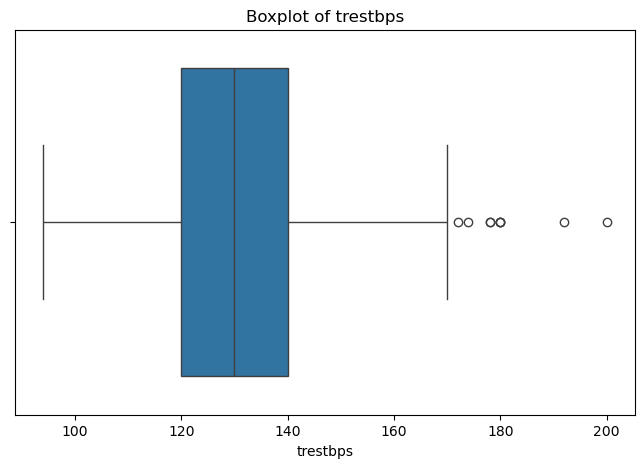

In [21]:
# boxplot of trestbps
plt.figure(figsize=(8,5))

sns.boxplot(x=df["trestbps"])

plt.title("Boxplot of trestbps")

plt.show()

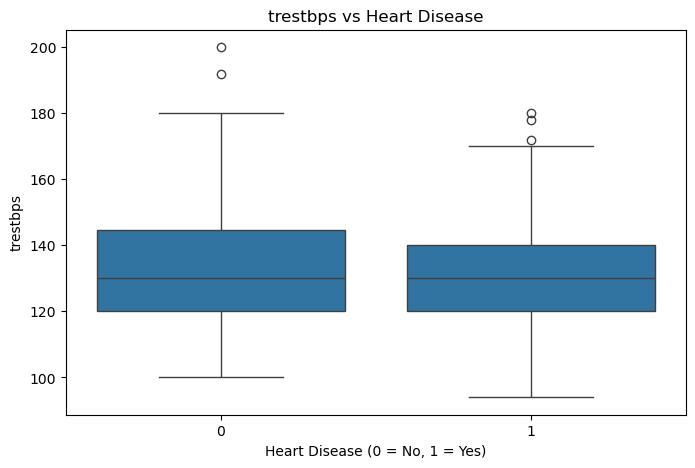

In [22]:
# box plot of trestbps Vs Target

plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="trestbps", data=df)

plt.title("trestbps vs Heart Disease")

plt.xlabel("Heart Disease (0 = No, 1 = Yes)")

plt.ylabel("trestbps")

plt.show()



# the median is around 130 

# both have around same median

# the data overlapps a lot

# outliers in both target =0 and 1

# and here the target=0 is more spread out

# Chol- cholestrol ( continuous value)

In [23]:
df["chol"].describe()

count    303.000000
mean     246.264026
std       51.830751
min      126.000000
25%      211.000000
50%      240.000000
75%      274.500000
max      564.000000
Name: chol, dtype: float64

In [24]:
# Q3-Q1
#Q3=274   Q1=211
# IQR=Q3-Q1=274.5-211=63.5
# lower bound=Q1-1.5*IQR=  211-1.5*63.5=115.75
# upper bound=Q3+1.5*IQR=  274.5+1.5*63.5=369.75

# minimum > lowerbound        126>115.75
# maximum < upper bound       564<369.75  X (there are outliers )
# there are  outliers

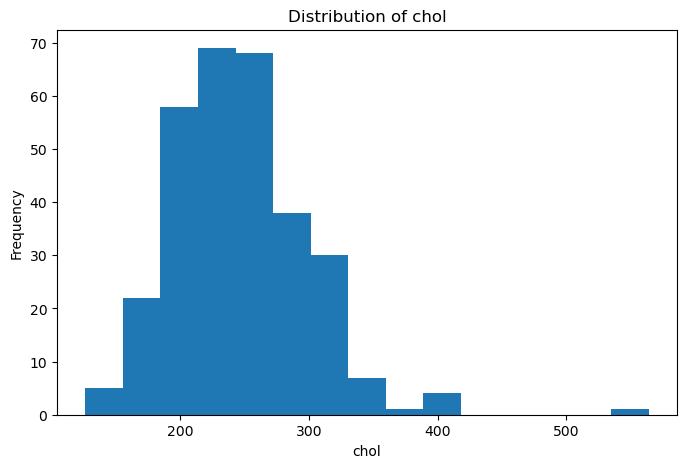

In [25]:
# distribuiton of chol


plt.figure(figsize=(8,5))
plt.hist(df["chol"], bins=15)
plt.title("Distribution of chol")
plt.xlabel("chol")
plt.ylabel("Frequency")
plt.show()

# it is  rgiht skwed because it has a long right tail
#the one peak point is between 200-300

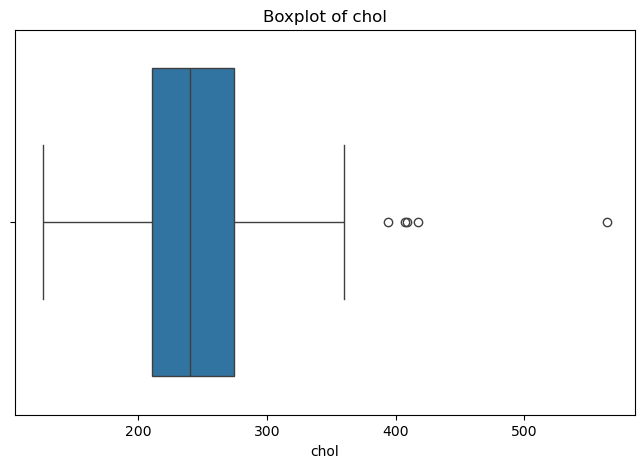

In [26]:
# boxplot of chol
plt.figure(figsize=(8,5))

sns.boxplot(x=df["chol"])

plt.title("Boxplot of chol")

plt.show()

# there are outliers in upper bound

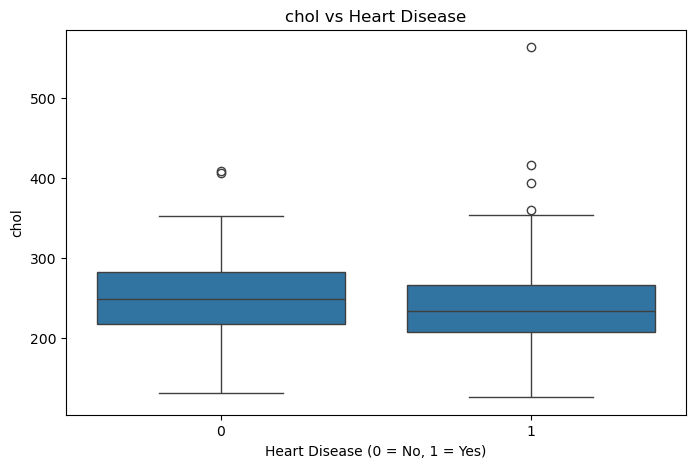

In [27]:
# box plot of chol Vs Target

plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="chol", data=df)

plt.title("chol vs Heart Disease")

plt.xlabel("Heart Disease (0 = No, 1 = Yes)")

plt.ylabel("chol")

plt.show()



# the median is around 250 for target=0
# median is around 230 for target=1

# both have outliers in upper bound but target=1 has more

# the data overlaps so we cant depend on this feature fully we need to consider with other features

# outliers in both target =0 and 1

# and here the target=0 is more spread out

# thalach - maximum heart rate(continuous value)


In [28]:
df["thalach"].describe()

count    303.000000
mean     149.646865
std       22.905161
min       71.000000
25%      133.500000
50%      153.000000
75%      166.000000
max      202.000000
Name: thalach, dtype: float64

In [29]:
# Q3-Q1
#Q3=166  Q1=133.5
# IQR=Q3-Q1=166-133.5=32.5
# lower bound=Q1-1.5*IQR=  133.5-1.5*32.5=84.75
# upper bound=Q3+1.5*IQR=  166+1.5*32.5=214.75

# minimum > lowerbound        71> 84.75 (false)
# maximum < upper bound       202<214.75  (True)
# there are  outliers

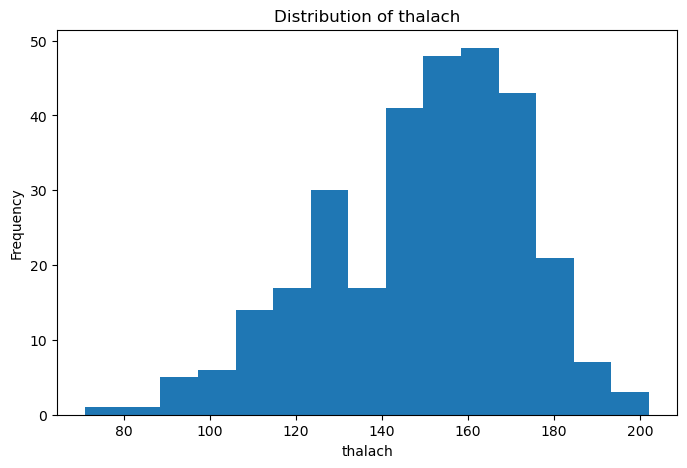

In [30]:
# distribuiton of thalach


plt.figure(figsize=(8,5))
plt.hist(df["thalach"], bins=15)
plt.title("Distribution of thalach")
plt.xlabel("thalach")
plt.ylabel("Frequency")
plt.show()

# it is  left skwed because it has a long left tail
#the one peak point is between 160-180

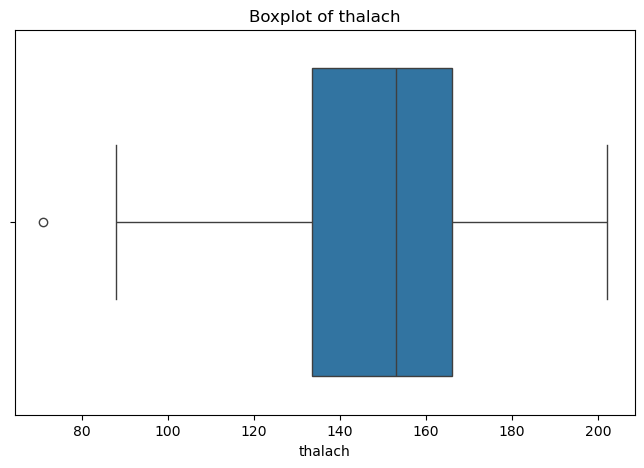

In [31]:
# boxplot of thalach
plt.figure(figsize=(8,5))

sns.boxplot(x=df["thalach"])

plt.title("Boxplot of thalach")

plt.show()

# there are outliers in lower bound

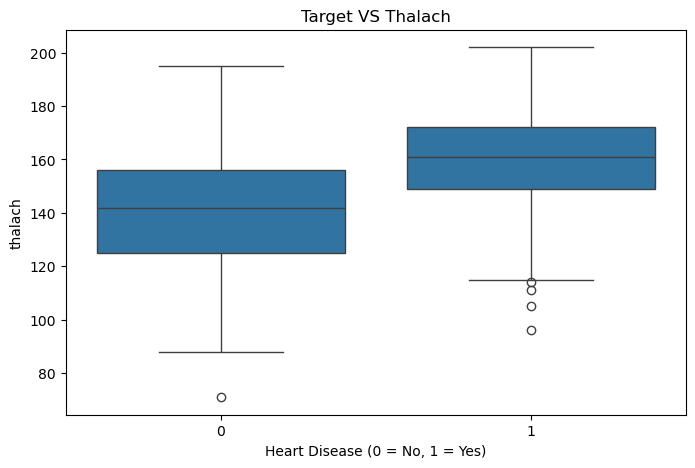

In [32]:
# boxplot thalach vs target
plt.figure(figsize=(8,5))
sns.boxplot(x="target",y="thalach",data=df)
plt.title("Target VS Thalach")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")

plt.ylabel("thalach")

plt.show()


Feature: maximum heart rate (thalach)

1. Distribution:
   left-skewed.

2. Outliers:
   lower outliers are present.

3. Relationship with Target:
   small overlap exists.
   Median values
    target 0=145
    target 1=160

4. ML Insight:
   maximum heart rate alone is a good predictor.
    but It should be retained because it may improve prediction when combined with other features.

## Old Peak- ST Depression - continuous value

In [33]:
df["oldpeak"].describe()

count    303.000000
mean       1.039604
std        1.161075
min        0.000000
25%        0.000000
50%        0.800000
75%        1.600000
max        6.200000
Name: oldpeak, dtype: float64

In [34]:
# Q3-Q1
#Q3=1.6  Q1=0
# IQR=Q3-Q1=1.6-0=1.6
# lower bound=Q1-1.5*IQR=  0-1.5*1.6=-2.4
# upper bound=Q3+1.5*IQR=  1.6+1.5*1.6=4

# minimum > lowerbound        0> -2.4 (true)
# maximum < upper bound       6.2<4  (false)
# there are  outliers

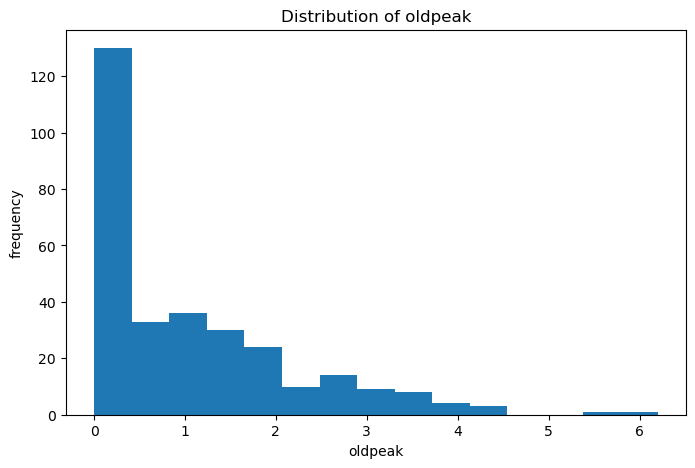

In [35]:
# distribution of oldpeak

plt.figure(figsize=(8,5))
plt.hist(df["oldpeak"],bins=15)
plt.title("Distribution of oldpeak")
plt.xlabel("oldpeak")
plt.ylabel("frequency")
plt.show()

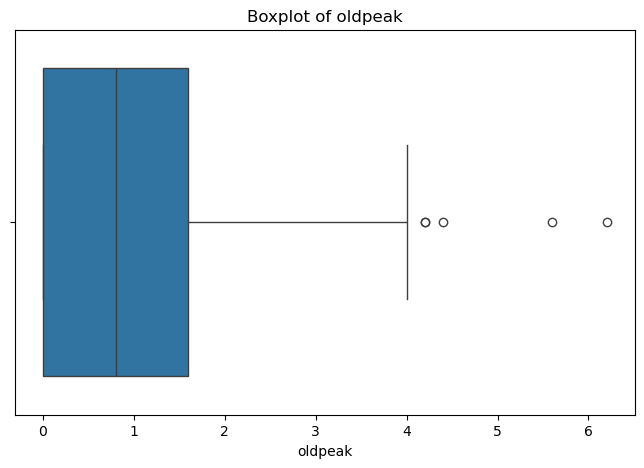

In [36]:
# boxplot of oldpeak

plt.figure(figsize=(8,5))
sns.boxplot(x=df["oldpeak"])
plt.title("Boxplot of oldpeak")

plt.show()

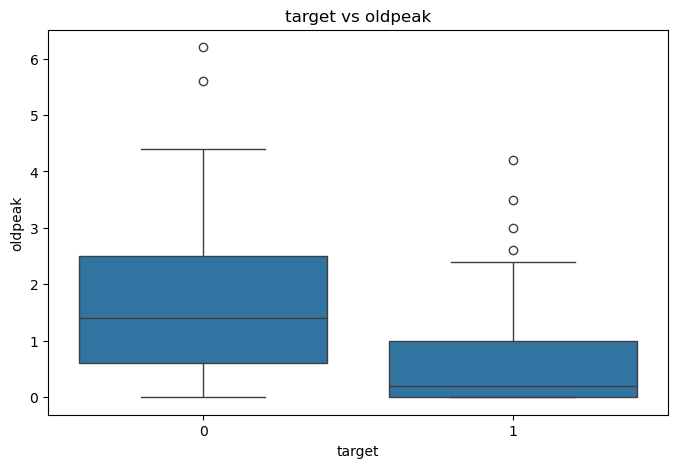

In [37]:
# boxplot of target vs oldpeak

plt.figure(figsize=(8,5))
sns.boxplot(x='target',y='oldpeak',data=df)
plt.title("target vs oldpeak")
plt.xlabel("target")
plt.ylabel("oldpeak")
plt.show()

Feature: oldpeak

1. Distribution:
   right-skewed.

2. Outliers:
   upper outliers are present.

3. Relationship with Target:
   small overlap exists.
   Median values
    target 0=1.5
    target 1=0.5
    target 0 has less outliers while compared to target1

4. ML Insight:
   oldpeak alone is a good predictor. it alone can be used for classification .
    but It should be retained because it may improve prediction when combined with other features.
5. decision:
    keep this feature


# categorical and binary features

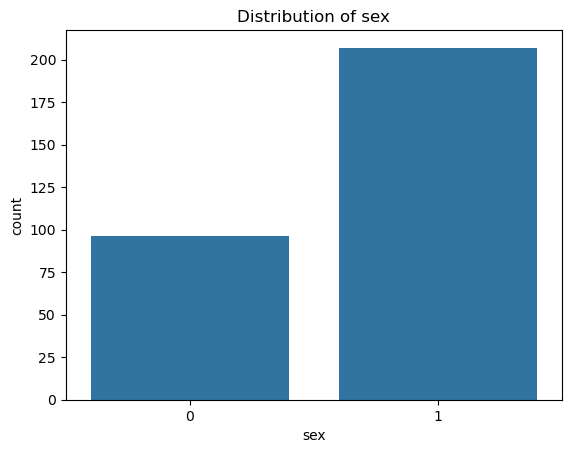

In [38]:
# sex-binary categorical feature.
# sex male=1 ,female=0
sns.countplot(x='sex',data=df)
plt.title("Distribution of sex")
plt.xlabel("sex")
plt.ylabel("count")
plt.show()

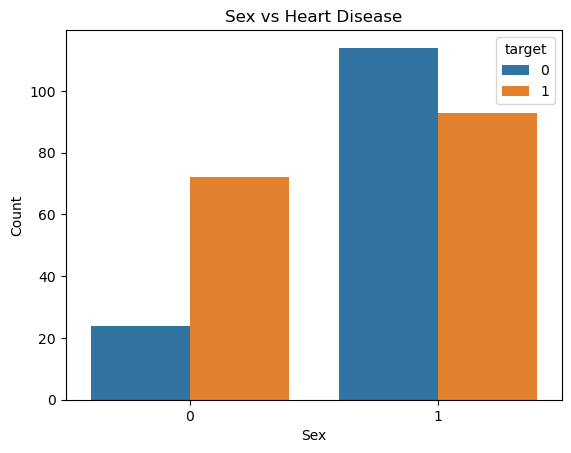

In [39]:
sns.countplot(x="sex", hue="target", data=df)

plt.title("Sex vs Heart Disease")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

In [40]:
pd.crosstab(df["sex"], df["target"], normalize="index") * 100

target,0,1
sex,,
0,25.000000,75.000000
1,55.072464,44.927536


Feature: sex

1. Distribution:
   The dataset contains considerably more male patients than female patients.

2. Relationship with Target:
   Female patients: 75% target = 1
   Male patients: 44.93% target = 1

3. ML Insight:
   There is a substantial difference in the target distribution between
   the two sex categories, suggesting that sex may be a useful predictor.

4. Decision:
   Keep the feature.

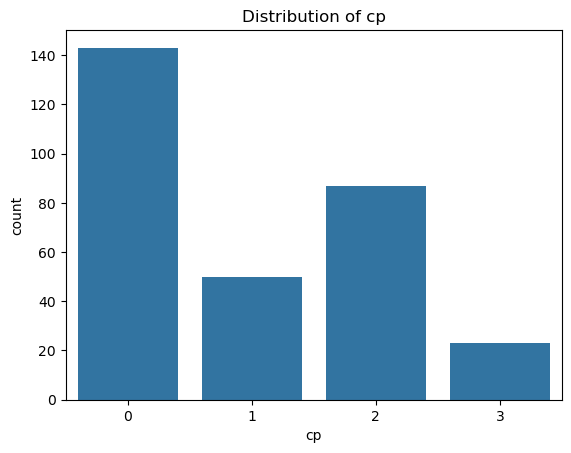

In [41]:
# CP -chest pain type  -categorical value

# cp - chest pain type
# 0: Typical angina: chest pain related decrease blood supply to the heart
# 1: Atypical angina: chest pain not related to heart
# 2: Non-anginal pain: typically esophageal spasms (non heart related)
# 3: Asymptomatic: chest pain not showing signs of disease


sns.countplot(x="cp",data=df)
plt.title("Distribution of cp")
plt.xlabel("cp")
plt.ylabel("count")
plt.show()

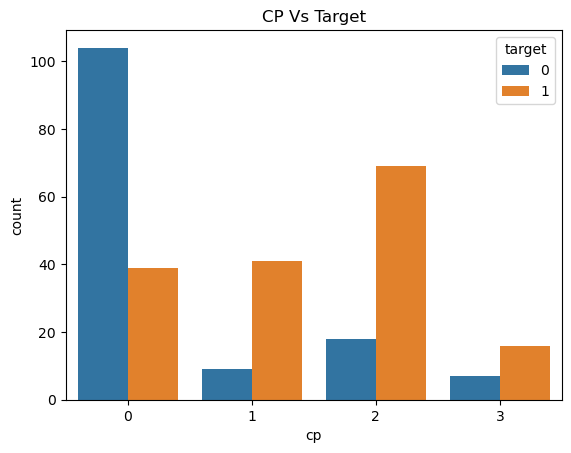

In [42]:
sns.countplot(x="cp",hue='target',data=df)
plt.title("CP Vs Target")
plt.xlabel("cp")
plt.ylabel("count")
plt.show()

In [43]:
pd.crosstab(df["cp"],df["target"],normalize="index")*100

target,0,1
cp,,
0,72.727273,27.272727
1,18.000000,82.000000
2,20.689655,79.310345
3,30.434783,69.565217


from this we can say that  category 1 has more chance of heart disease even though the count of category 0 is more
so from this we can conclude it is a useful feature

Feature: cp (Chest Pain Type)

1. Distribution:
   The four categories have different frequencies.
   CP = 0 is the most common category, while CP = 3 is the least common.

2. Relationship with Target:
   CP = 0 → 27.27% target = 1
   CP = 1 → 82.00% target = 1
   CP = 2 → 79.31% target = 1
   CP = 3 → 69.57% target = 1

3. ML Insight:
   There is a strong difference in target distribution across CP categories.
   Therefore, CP appears to be a highly informative feature.

4. Decision:
   Keep the feature.

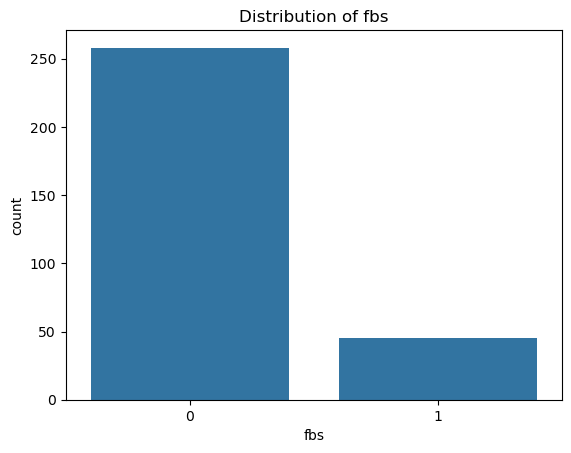

In [44]:
##fbs- fasting blood sugar
sns.countplot(x='fbs',data=df)
plt.title('Distribution of fbs')
plt.xlabel('fbs')
plt.ylabel('count')
plt.show()

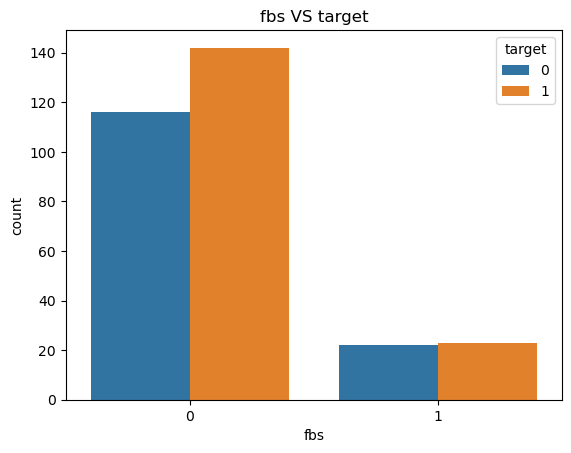

In [45]:
sns.countplot(x='fbs',hue='target',data=df)
plt.title('fbs VS target')
plt.xlabel('fbs')
plt.ylabel('count')
plt.show()

In [46]:
pd.crosstab(df['fbs'],df['target'],normalize='index')*100

target,0,1
fbs,,
0,44.961240,55.038760
1,48.888889,51.111111


In [47]:
temp=df[[ 'restecg','exang',  'slope', 'ca', 'thal', 'target']]


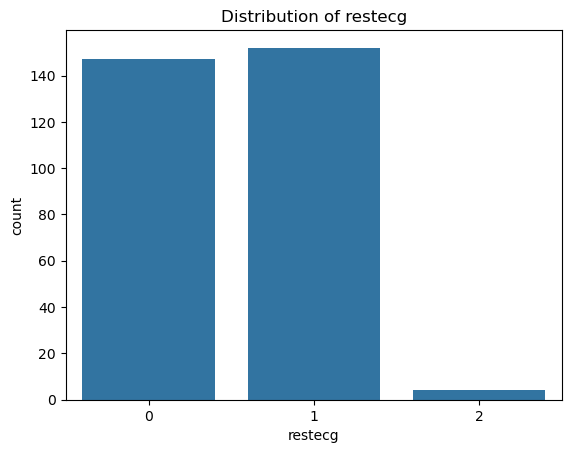

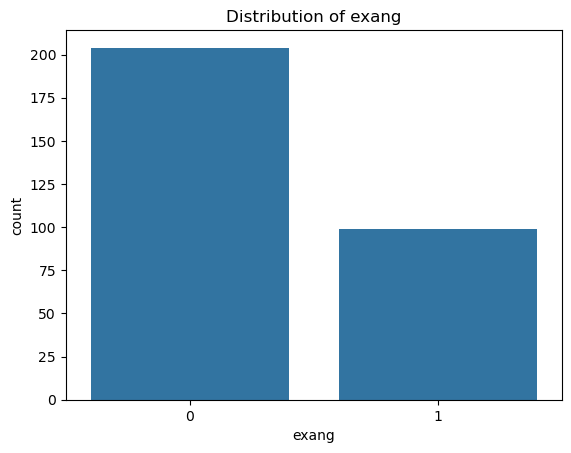

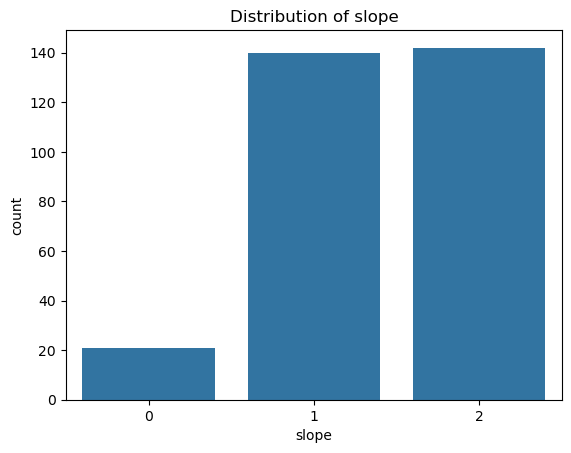

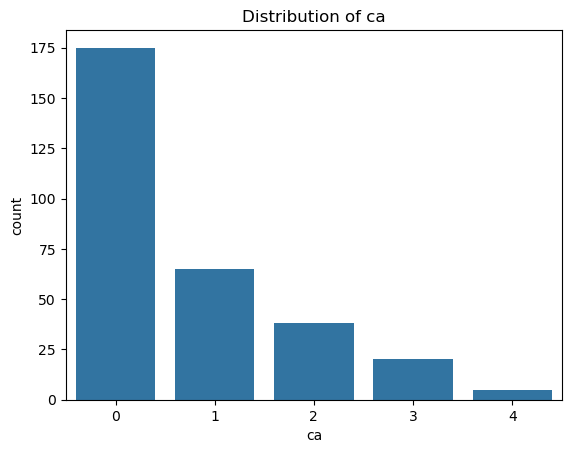

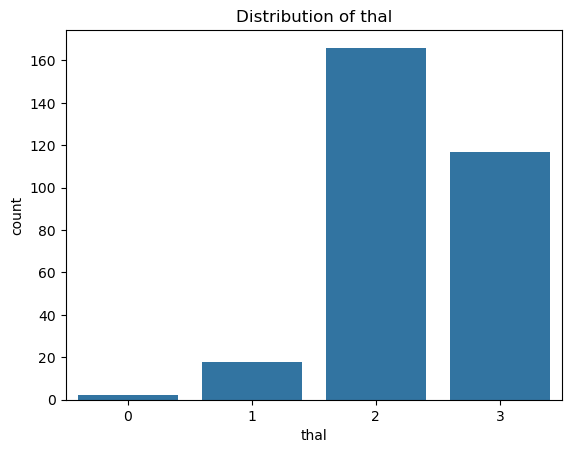

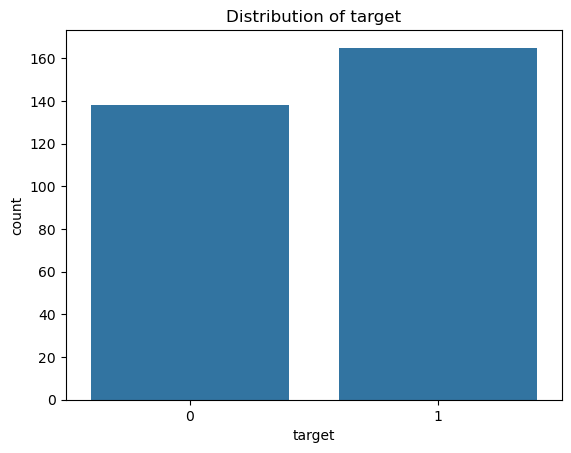

In [48]:
for x in temp.columns:
    sns.countplot(x=x,data=temp)
    plt.title(f"Distribution of {x}")
    plt.xlabel(x)
    plt.ylabel('count')
    plt.show()
 

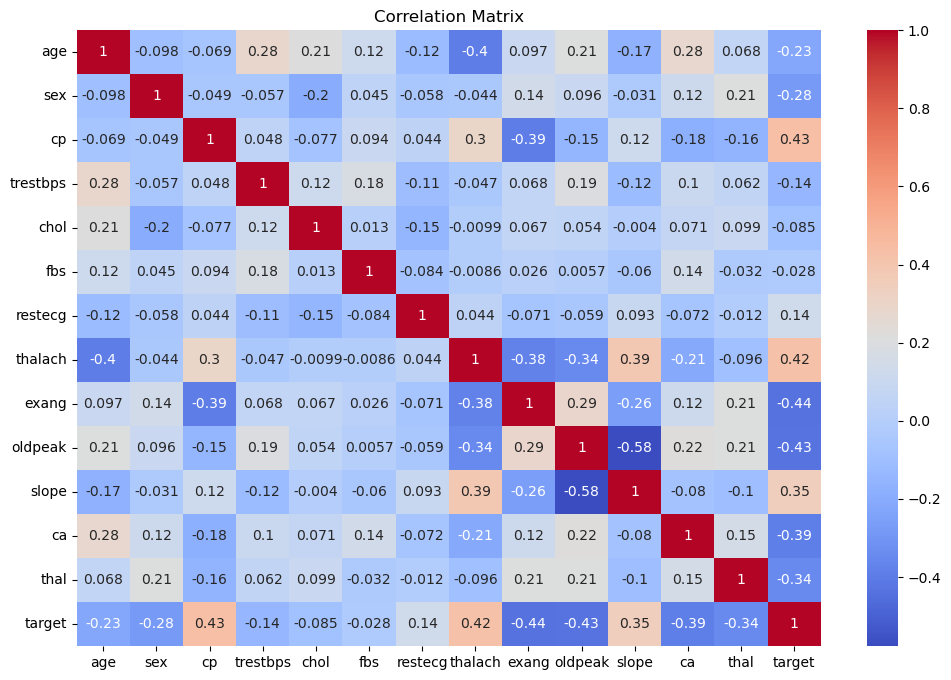

In [49]:
## correlation matrix

plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

# Feature selection 

### using L1 Reqularization (lasso)

In [50]:
# lasso is sensitive to  feature scale 
# we need to do scaling


X = df.drop("target", axis=1)
y = df["target"]

In [51]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y    # it helps us in maintaining same proportion(0 or 1) in both train and test data
)   

In [52]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (242, 13)
X_test : (61, 13)
y_train: (242,)
y_test : (61,)


In [53]:
# ## scaling the data

# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_train_scaled = scaler.fit_transform(X_train)

# X_test_scaled = scaler.transform(X_test)
# print(X_train_scaled.shape)
# # print(X_test_scaled.shape)

# from sklearn.linear_model import LogisticRegression

# model=LogisticRegression(
    
#     penalty="l1",
#     solver="liblinear",
#     C=1
# )

# model.fit(X_train_scaled, y_train)




What is an ML Pipeline?

A pipeline is simply a way of putting multiple ML steps together in the correct order.

Instead of manually doing those steps separately, we can tell Scikit-learn:

"Whenever you train this model, first scale the data, then train the model."

That's a Pipeline.

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

In [55]:
from sklearn.model_selection import cross_val_score,StratifiedKFold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("CV scores:", scores)
print("Mean CV accuracy:", scores.mean())

CV scores: [0.81632653 0.91836735 0.625      0.83333333 0.875     ]
Mean CV accuracy: 0.8136054421768708


In [56]:
logistic_model.fit(X_train, y_train)
y_pred = logistic_model.predict(X_test)


print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61

[[19  9]
 [ 3 30]]


In [73]:
# saving the pipleline of this project so that we dont need to run python file everytime 

import joblib

joblib.dump(logistic_model, "heart_disease_model.pkl")

loaded_model = joblib.load("heart_disease_model.pkl")

# predictions = loaded_model.predict(X_test)

# print(predictions)

In [74]:
# import pandas as pd

# new_patient = pd.DataFrame([{
#     "age": 55,
#     "sex": 1,
#     "cp": 2,
#     "trestbps": 140,
#     "chol": 240,
#     "fbs": 0,
#     "restecg": 1,
#     "thalach": 150,
#     "exang": 0,
#     "oldpeak": 1.2,
#     "slope": 1,
#     "ca": 0,
#     "thal": 2
# }])

In [75]:
# probability = loaded_model.predict_proba(new_patient)

# print(probability)

In [91]:

def predict_heart_disease( age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal):
    
    patient = pd.DataFrame([{
        "age": age,
        "sex": sex,
        "cp": cp,
        "trestbps": trestbps,
        "chol": chol,
        "fbs": fbs,
        "restecg": restecg,
        "thalach": thalach,
        "exang": exang,
        "oldpeak": oldpeak,
        "slope": slope,
        "ca": ca,
        "thal": thal
    }])
    
    prediction = loaded_model.predict(patient)[0]
    probability = loaded_model.predict_proba(patient)[0]

    if prediction == 1:
        print("Heart disease: Positive")
    else:
        print("Heart disease: Negative")
    
    print(f"Class 0 probability: {probability[0] * 100:.2f}%")
    print(f"Class 1 probability: {probability[1] * 100:.2f}%")
    
    # return prediction, probability

In [92]:
predict_heart_disease(
    55,
    1,
    2,
    140,
    240,
    0,
    1,
    150,
    0,
    1.2,
    1,
    0,
    2
)

print("Prediction:", prediction)
print("Probability:", probability)

Heart disease: Positive
Class 0 probability: 16.45%
Class 1 probability: 83.55%
Prediction: 1
Probability: [0.16452447 0.83547553]


In [66]:
# # moving to svm
# from sklearn.svm import SVC

# svm_linear = Pipeline([
#     ("scaler", StandardScaler()),
#     ("classifier", SVC(kernel="rbf"))
# ])

In [67]:
# scores_svm = cross_val_score(
#     svm_linear,
#     X_train,
#     y_train,
#     cv=cv,
#     scoring="accuracy"
# )

# print("SVM CV scores:", scores_svm)
# print("Mean SVM CV accuracy:", scores_svm.mean())

In [59]:
# svm_linear.fit(X_train, y_train)

# y_pred_svm_rbf = svm_linear.predict(X_test)

In [60]:
# from sklearn.metrics import classification_report

# print("LOGISTIC REGRESSION")
# print(classification_report(y_test, y_pred))

# print("LINEAR SVM")
# print(classification_report(y_test, y_pred_svm_linear))

# # print("RBF SVM")
# # print(classification_report(y_test, y_pred_svm_rbf))